In [21]:
import cv2, glob, os
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from skimage.metrics import hausdorff_distance

DATA = "Materials"
%matplotlib inline

In [22]:
def get_contour(img):
    fg = (img < 128).astype(np.uint8)
    # RETR_EXTERNAL -> tylko zew kontur, CHAIN_APPROX_NONE -> wszystkie punkty
    cnts, _ = cv2.findContours(fg, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    return max(cnts, key=cv2.contourArea)[:, 0, :].astype(float)

def normalize(pts):
    pts = pts - pts.mean(0) # srodek -> (0, 0)
    return pts / np.sqrt((pts ** 2).sum(1)).max() # max odleglosc -> 1

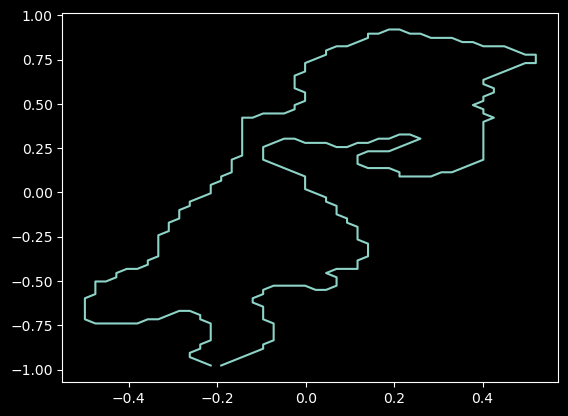

max promień po normalizacji: 1.0


In [ ]:
q_raw = get_contour(cv2.imread(f"{DATA}/ithaca_q.bmp", 0))
q = normalize(q_raw)

plt.plot(q[:, 0], q[:, 1])
plt.show()
print("max promien po normalizacji:", round(np.sqrt((q ** 2).sum(1)).max(), 4))

max przed normalizacją: 89.4707


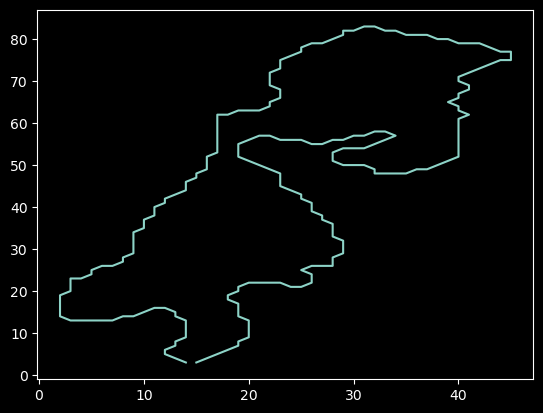

In [32]:
plt.plot(q_raw[:, 0], q_raw[:, 1])
print("max przed normalizacją:", round(np.sqrt((q_raw ** 2).sum(1)).max(), 4))

In [33]:
def hausdorff(A, B):
    D = cdist(A, B)
    return max(D.min(1).max(),
               D.min(0).max())

In [36]:
# porwnanie z gotowa funkcja

a = cv2.imread(f"{DATA}/ithaca_q.bmp", 0) < 128
b = cv2.imread(f"{DATA}/imgs/i_ithaca.bmp", 0) < 128
mine = hausdorff(np.argwhere(a), np.argwhere(b))
ref  = hausdorff_distance(a, b)
print(f"moje: {mine:.6f}")
print(f"skimage: {ref:.6f}")

moje: 58.523500
skimage: 58.523500


In [37]:
def load_templates():
    T = {}
    for f in sorted(glob.glob(f"{DATA}/imgs/*.bmp")):
        name = os.path.splitext(os.path.basename(f))[0].split("_", 1)[1]
        T[name] = normalize(get_contour(cv2.imread(f, 0)))
    return T

templates = load_templates()
print(len(templates), list(templates)[:8])

70 ['amorgos', 'anafi', 'andros', 'antiparos', 'astipalea', 'folegandros', 'giaros', 'ios']


In [38]:
def match(pts, T):
    return sorted((hausdorff(pts, t), nm) for nm, t in T.items())

ranking = match(q, templates)
for d, name in ranking[:5]:
    print(d, name)

0.03145480875788188 ithaca
0.2758000441489656 rinia
0.3237575849101658 andros
0.326442965014821 antikythira
0.34119131668946695 skantzoura


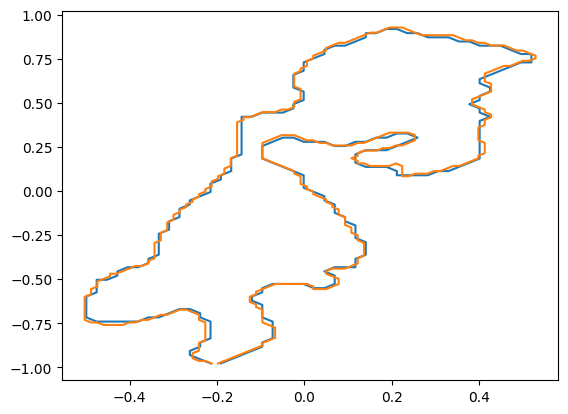

In [8]:
best = templates[ranking[0][1]]
plt.plot(q[:, 0], q[:, 1])
plt.plot(best[:, 0], best[:, 1])
plt.show()

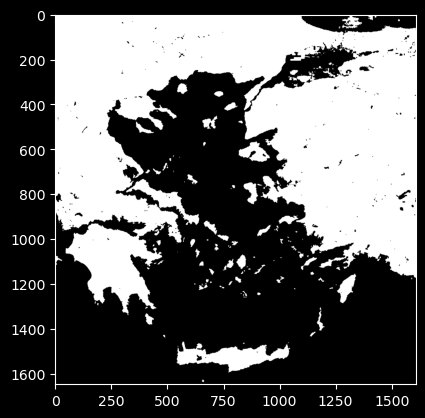

In [39]:
img = cv2.imread(f"{DATA}/Aegeansea.jpg")
B, G, R = (img[:, :, i].astype(int) for i in range(3))
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
S = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)[:, :, 1]

# wiecej R - > lad, ale nie za jasne i nie za malo nasycone (chmury)
land = ((R >= B) & ~((gray > 160) & (S < 60))).astype(np.uint8)

# morfologia
k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
land = cv2.morphologyEx(land, cv2.MORPH_OPEN, k)
land = cv2.morphologyEx(land, cv2.MORPH_CLOSE, k)

plt.imshow(land, cmap="gray")

In [ ]:
n, lab, stats, cent = cv2.connectedComponentsWithStats(land, 8)
H, W = land.shape

# odrzucamy zbyt male i zbyt duze
islands = []
for i in range(1, n):
    x, y, w, h, area = stats[i]
    if area < 150 or area > 40000:
        continue   # szum lub zbyt duze
    if x <= 1 or y <= 1 or x + w >= W - 1 or y + h >= H - 1:
        continue   # czy nie dotyka brzegu
    cnts, _ = cv2.findContours((lab == i).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    c = max(cnts, key=cv2.contourArea)[:, 0, :].astype(float)
    if len(c) < 10:
        continue # zbyt malo pkt
    islands.append((normalize(c), cent[i]))
print("wykrytych wysp-kandydatów:", len(islands))

wykrytych wysp-kandydatów: 44


In [41]:
TH = 0.25
results = []   # (srodek, nazwa, dystans)
for pts, c in islands:
    d, nm = match(pts, templates)[0]
    results.append((c, nm, d))

for c, nm, d in sorted(results, key=lambda r: r[2]):
    flag = "OK " if d < TH else "  ?"
    print(f"{flag} {nm:14s} d={d:.3f}  @({int(c[0])},{int(c[1])})")

OK  samothraki     d=0.125  @(729,354)
OK  kos            d=0.134  @(1129,1105)
OK  hios           d=0.139  @(875,792)
OK  limnos         d=0.143  @(688,484)
OK  naxos          d=0.143  @(831,1103)
OK  tinos          d=0.149  @(751,994)
OK  kea            d=0.154  @(612,1016)
OK  samos          d=0.154  @(1037,914)
OK  andros         d=0.159  @(693,947)
OK  sikinos        d=0.161  @(1146,1424)
OK  skopelos       d=0.166  @(454,702)
OK  kalimnos       d=0.172  @(1095,1073)
OK  thasos         d=0.179  @(566,331)
OK  kythira        d=0.184  @(418,1359)
OK  alonissos      d=0.188  @(489,678)
OK  ikaria         d=0.190  @(928,965)
OK  rithnos        d=0.192  @(634,1063)
OK  ios            d=0.197  @(815,1182)
OK  serifos        d=0.199  @(652,1112)
OK  karpathos      d=0.209  @(1181,1372)
OK  kea            d=0.210  @(1298,1219)
OK  nissiros       d=0.223  @(1144,1154)
OK  skiathos       d=0.223  @(412,701)
OK  andros         d=0.239  @(1063,1042)
OK  ios            d=0.240  @(995,1189)
OK 

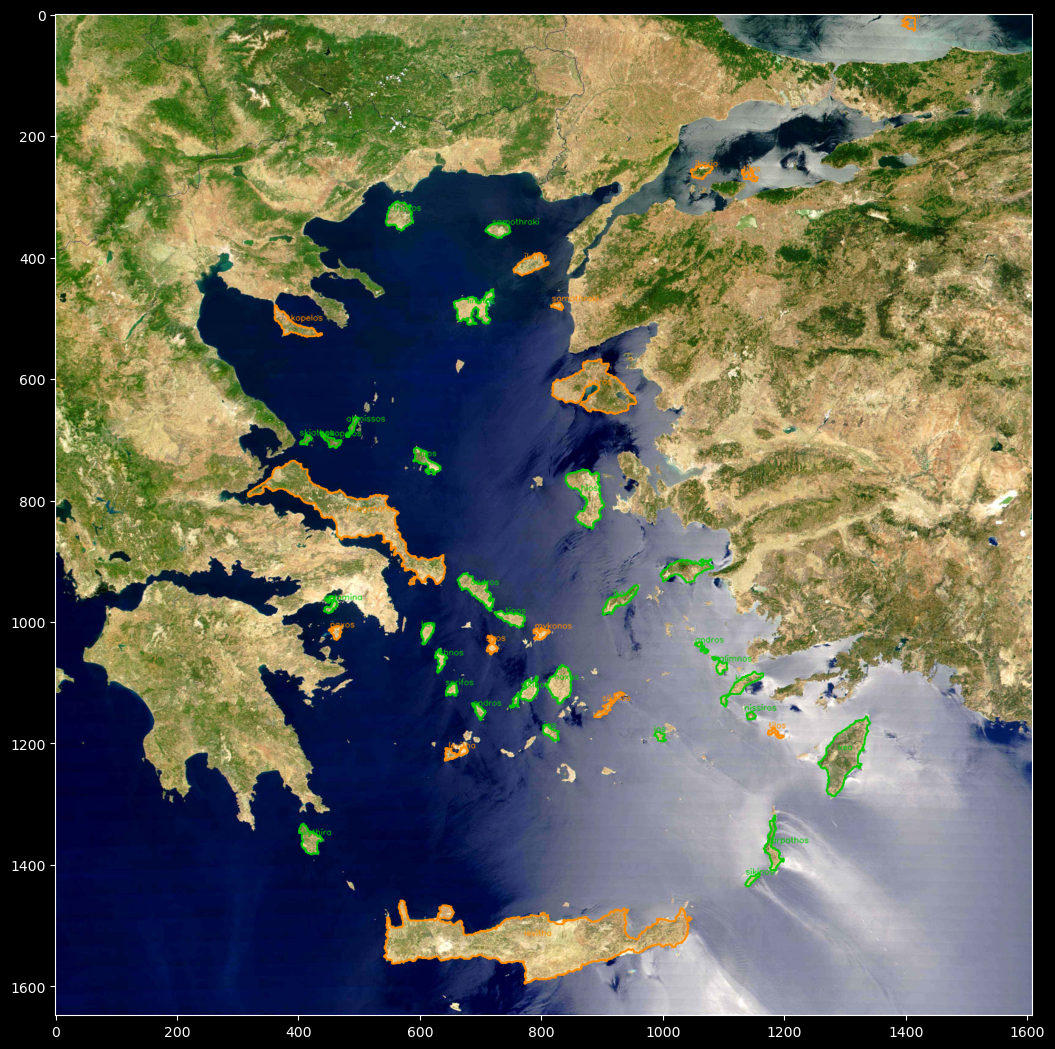

In [42]:
vis = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).copy()
for i in range(1, n):
    x, y, w, h, area = stats[i]
    if area < 150 or area > 40000 or x <= 1 or y <= 1 or x + w >= W - 1 or y + h >= H - 1:
        continue
    cnts, _ = cv2.findContours((lab == i).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    c = max(cnts, key=cv2.contourArea)
    if len(c[:, 0, :]) < 10: continue
    d, nm = match(normalize(c[:, 0, :].astype(float)), templates)[0]
    col = (0, 200, 0) if d < TH else (255, 140, 0)
    cv2.drawContours(vis, [c], -1, col, 2)
    cx, cy = cent[i]
    cv2.putText(vis, nm, (int(cx) - 10, int(cy) - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.45, col, 1, cv2.LINE_AA)

plt.figure(figsize=(13, 13))
plt.imshow(vis)
plt.show()